In [33]:
import gc
from pathlib import Path
import pandas as pd
import geopandas as gpd
import numpy as np
import pyreadstat
import matplotlib.pyplot as plt
import seaborn as sns

data_dir = Path(Path.cwd()).parent / "Data"
plot_dir = Path(Path.cwd()) / 'Plots'

In [34]:
# Shapefiles
kreise = gpd.read_file(Path(data_dir / "Shapefiles-2022" / "Germany" / "COUNTIES" / "VG250_KRS_clean_final.shp"))

# Join county_id 16056 into county_id 16063
from shapely.ops import unary_union
kreise.loc[kreise["RS"].isin(["16056", "16063"]), "geometry"] = unary_union(
    kreise.loc[kreise["RS"].isin(["16056", "16063"]), "geometry"]
)
kreise = gpd.GeoDataFrame(kreise[~kreise["RS"].isin(["16056"])].copy())

In [35]:
# Translate the R block to pandas
labour_data = pd.read_excel(
    Path(data_dir / "county-wages-2022" / "country-wages-2022-entgelt-dwolk-0-202212-xlsx.xlsx"),
    sheet_name="8.1",
    usecols="A:K",
    skiprows=8,
    nrows=6287,
    dtype=str,
 )
# Stichtag 31.12.2024

# Rename and keep relevant variables (columns 1:4 and 11 in R's 1-based indexing)
labour_data = labour_data.iloc[:, [0, 1, 2, 3, 10]].copy()
labour_data.columns = [
    "AGS",      # Region key (Amtlicher Gemeindeschluessel)
    "region",
    "merkmale",
    "N",        # total workers
    "wages",    # median euro
 ]

# Select counties only
labour_data["AGS"] = labour_data["AGS"].astype("string").str.strip()
labour_data["RS"] = labour_data["AGS"]
labour_data = labour_data[labour_data["AGS"].str.len() == 5].copy()

# Select correct qualifications only
labour_data = labour_data[labour_data["merkmale"].isin([
    "ohne Berufsabschluss",
    "anerkannter Berufsabschluss",
    "akademischer Berufsabschluss",
    "Insgesamt",
])].copy()

labour_data.head()

,AGS,region,merkmale,N,wages,RS
286,01001,"Flensburg, Stadt",Insgesamt,25761,3433.1826196473553,01001
294,01001,"Flensburg, Stadt",ohne Berufsabschluss,2182,2395.6923076923076,01001
295,01001,"Flensburg, Stadt",anerkannter Berufsabschluss,16986,3409.590909090909,01001
296,01001,"Flensburg, Stadt",akademischer Berufsabschluss,4602,4891.728070175439,01001
301,01002,"Kiel, Landeshauptstadt",Insgesamt,77066,3772.814049586777,01002


In [36]:
purchase_price_index = pd.read_csv("purchase_price_index.csv")
rental_price_index = pd.read_csv("rental_price_index.csv")

purchase_price_index['county_id'] = purchase_price_index['county_id'].astype(str).str.zfill(5)
rental_price_index['county_id'] = rental_price_index['county_id'].astype(str).str.zfill(5)

In [37]:
data = labour_data
for id in data['AGS'].unique():
    data.loc[data['AGS'] == id, 'purchase_price_index'] = purchase_price_index.loc[purchase_price_index['county_id'] == id, 'purchase_price_index'].values[0]
    data.loc[data['AGS'] == id, 'rental_price_index'] = rental_price_index.loc[rental_price_index['county_id'] == id, 'rental_price_index'].values[0]

In [38]:
# If X, then np.nan. If > or < then the number without the symbol.
# Numbers are in format e.g. 2621.298319327731 
def convert_wages(value):
    if value == 'X':
        return np.nan
    elif value.startswith('>'):
        return float(value[1:].strip().replace('.', ''))
    elif value.startswith('<'):
        return float(value[1:].strip().replace('.', ''))
    else:
        return float(value.strip())

v_convert_wages = np.vectorize(convert_wages)
data['wages'] = v_convert_wages(data['wages'])
data['N'] = data['N'].astype(float)

In [39]:
# Set up
# Input share of labour
alpha = 2/3
# Expenditure share of housing
sigma = 1/3
# Height elasticity of construction cost
delta = 3/2

# beta = (1+ (1-alpha)*b_w^*)/(1+b_w^*) <- to be estimated in the next step

In [40]:
# Estimate b_w^* for each skill group

skill_groups = data['merkmale'].unique()
# Create logs of wage and labour supply
data['log_wages'] = np.log(data['wages'])
data['log_N'] = np.log(data['N'])

import statsmodels.formula.api as smf

b_w_stars = {}
for skill in skill_groups:
    formula = f"log_wages ~ log_N"
    model = smf.ols(formula=formula, data=data[data['merkmale'] == skill]).fit()
    b_w_stars[skill] = model.params['log_N']
    
# Infer beta from b_w^* for each skill group
cobb_douglas_params = {'alpha': alpha, 'sigma': sigma, 'delta': delta, 'beta': {skill: (1 + (1 - alpha) * b_w_stars[skill]) / (1 + b_w_stars[skill]) for skill in skill_groups}}
data['beta'] = data['merkmale'].map(cobb_douglas_params['beta'])

In [41]:
# First the purchase price index
data['pp_qol'] = -data['log_wages'] + sigma * data['purchase_price_index']
data['pp_fund_prod'] = (1-data['beta']) * data['log_wages'] + (1-cobb_douglas_params['alpha'] - data['beta']) * data['log_N']
data['pp_eff_land_supply'] = data['log_wages'] + data['log_N'] - (cobb_douglas_params['delta']/(cobb_douglas_params['delta']-1)) * data['purchase_price_index']

# demean inside the skill groups
data['pp_qol_demeaned'] = data.groupby('merkmale')['pp_qol'].transform(lambda x: x - x.mean())
data['pp_fund_prod_demeaned'] = data.groupby('merkmale')['pp_fund_prod'].transform(lambda x: x - x.mean())
data['pp_eff_land_supply_demeaned'] = data.groupby('merkmale')['pp_eff_land_supply'].transform(lambda x: x - x.mean())

# Now the rental price index
data['rp_qol'] = -data['log_wages'] + sigma * data['rental_price_index']
data['rp_fund_prod'] = (1-data['beta']) * data['log_wages'] + (1-cobb_douglas_params['alpha'] - data['beta']) * data['log_N']
data['rp_eff_land_supply'] = data['log_wages'] + data['log_N'] - (cobb_douglas_params['delta']/(cobb_douglas_params['delta']-1)) * data['rental_price_index']

# demean inside the skill groups
data['rp_qol_demeaned'] = data.groupby('merkmale')['rp_qol'].transform(lambda x: x - x.mean())
data['rp_fund_prod_demeaned'] = data.groupby('merkmale')['rp_fund_prod'].transform(lambda x: x - x.mean())
data['rp_eff_land_supply_demeaned'] = data.groupby('merkmale')['rp_eff_land_supply'].transform(lambda x: x - x.mean())

In [42]:
# Set up for plotting
# Params for clean and minimalistic plots
sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.figsize': (6*2, 2*4.5),
    'font.size': 14.0,
    'font.family': 'serif',
    'font.serif': 'Palatino',
    'axes.titlesize': 'medium',
    'figure.titlesize': 'large',
    'legend.fontsize': 'medium',
    # dpi for high-res output
    'figure.dpi': 100,
    'savefig.dpi': 300,
    # Tight layout by default
    'figure.autolayout': True,
    'text.usetex': True,
    'text.latex.preamble': r"\usepackage{amsmath}\usepackage{amssymb}\usepackage{siunitx}[=v2]",
})

In [43]:
# Plotting on a map
'''
for skill in skill_groups:
    data_skill = data[data['merkmale'] == skill].copy()
    merged = kreise.merge(data_skill, left_on='RS', right_on='AGS')
    # Plot all 3 demeaned variables in a 1-row subplot with proper spacing
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    merged.plot(column='qol', cmap='viridis', legend=True, ax=axes[0], linewidth=0.1, edgecolor='white')
    axes[0].set_title(f'Quality of Life\n(demeaned)\n{skill}')
    axes[0].axis('off')
    merged.plot(column='fund_prod', cmap='viridis', legend=True, ax=axes[1], linewidth=0.1, edgecolor='white')
    axes[1].set_title(f'Fundamental Productivity\n(demeaned)\n{skill}')
    axes[1].axis('off')
    merged.plot(column='eff_land_supply', cmap='viridis', legend=True, ax=axes[2], linewidth=0.1, edgecolor='white')
    axes[2].set_title(f'Efficient Land Supply\n(demeaned)\n{skill}')
    axes[2].axis('off')
    plt.suptitle(f'Spatial Distribution of Key Variables for {skill}', fontsize=16)
    plt.tight_layout()
    plt.savefig(plot_dir / f'spatial_distribution_{skill}.png', bbox_inches='tight', dpi=150)
    plt.show()
'''

"\nfor skill in skill_groups:\n    data_skill = data[data['merkmale'] == skill].copy()\n    merged = kreise.merge(data_skill, left_on='RS', right_on='AGS')\n    # Plot all 3 demeaned variables in a 1-row subplot with proper spacing\n    fig, axes = plt.subplots(1, 3, figsize=(18, 6))\n    merged.plot(column='qol', cmap='viridis', legend=True, ax=axes[0], linewidth=0.1, edgecolor='white')\n    axes[0].set_title(f'Quality of Life\n(demeaned)\n{skill}')\n    axes[0].axis('off')\n    merged.plot(column='fund_prod', cmap='viridis', legend=True, ax=axes[1], linewidth=0.1, edgecolor='white')\n    axes[1].set_title(f'Fundamental Productivity\n(demeaned)\n{skill}')\n    axes[1].axis('off')\n    merged.plot(column='eff_land_supply', cmap='viridis', legend=True, ax=axes[2], linewidth=0.1, edgecolor='white')\n    axes[2].set_title(f'Efficient Land Supply\n(demeaned)\n{skill}')\n    axes[2].axis('off')\n    plt.suptitle(f'Spatial Distribution of Key Variables for {skill}', fontsize=16)\n    plt.tig

In [44]:
# === PANEL SETUP: EXOGENOUS FACTORS ACROSS SKILL GROUPS ===
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Ordered skill groups and display labels
SKILL_ORDER = [
    "Insgesamt",
    "ohne Berufsabschluss",
    "anerkannter Berufsabschluss",
    "akademischer Berufsabschluss",
]
SKILL_LABELS = {
    "Insgesamt":                    r"Total",
    "ohne Berufsabschluss":         r"No Vocational Qualification",
    "anerkannter Berufsabschluss":  r"Vocational Qualification",
    "akademischer Berufsabschluss": r"Academic Qualification",
}

# Recompute demeaned values correctly (demean within skill group)
for _col in ["pp_qol", "pp_fund_prod", "pp_eff_land_supply"]:
    data[f"{_col}_dm"] = data.groupby("merkmale")[_col].transform(lambda x: x - x.mean())

# Map bounds (shared across all panels)
_bounds = kreise.total_bounds
xlim = (_bounds[0], _bounds[2])
ylim = (_bounds[1], _bounds[3])

def plot_with_bottom_colorbar(gdf, column, ax, cmap, vmin, vmax):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("bottom", size="5%", pad=0.12)
    gdf.plot(
        column=column,
        ax=ax,
        cmap=cmap,
        edgecolor="black",
        linewidth=0.2,
        legend=True,
        vmin=vmin,
        vmax=vmax,
        cax=cax,
        legend_kwds={"orientation": "horizontal"},
    )
    cax.tick_params(labelsize=10)


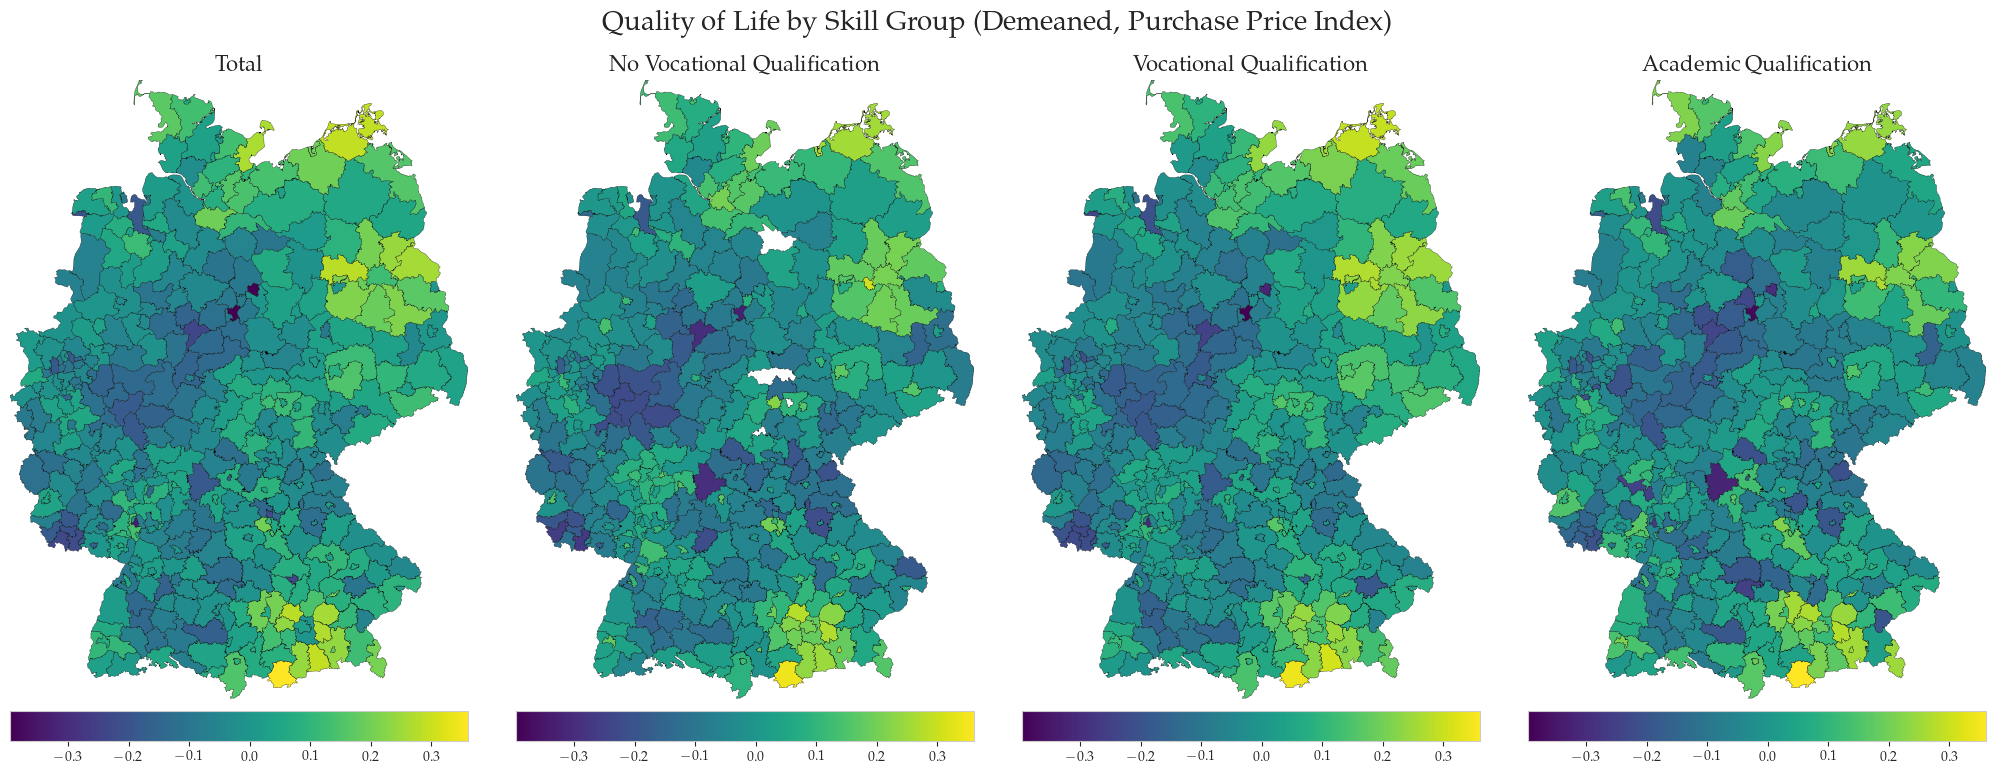

In [45]:
# === PANEL 1: QUALITY OF LIFE (demeaned within skill group) ===
_col = "pp_qol_dm"
_vmin, _vmax = data[_col].min(), data[_col].max()

fig, axes = plt.subplots(1, 4, figsize=(22, 8))

for ax, skill in zip(axes, SKILL_ORDER):
    skill_df = data.loc[data["merkmale"] == skill, ["AGS", _col]].copy()
    gdf = kreise.merge(skill_df, left_on="RS", right_on="AGS", how="left")
    plot_with_bottom_colorbar(gdf, _col, ax, "viridis", _vmin, _vmax)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(SKILL_LABELS[skill], fontsize=16, fontweight="bold")
    ax.set_axis_off()

plt.suptitle(
    r"Quality of Life by Skill Group (Demeaned, Purchase Price Index)",
    fontsize=20, fontweight="bold", y=0.97,
)
plt.subplots_adjust(left=0.01, right=0.99, top=0.89, bottom=0.08, wspace=0.05)
plt.savefig(plot_dir / "panel_qol_by_skill.png", bbox_inches="tight", dpi=150)
plt.show()


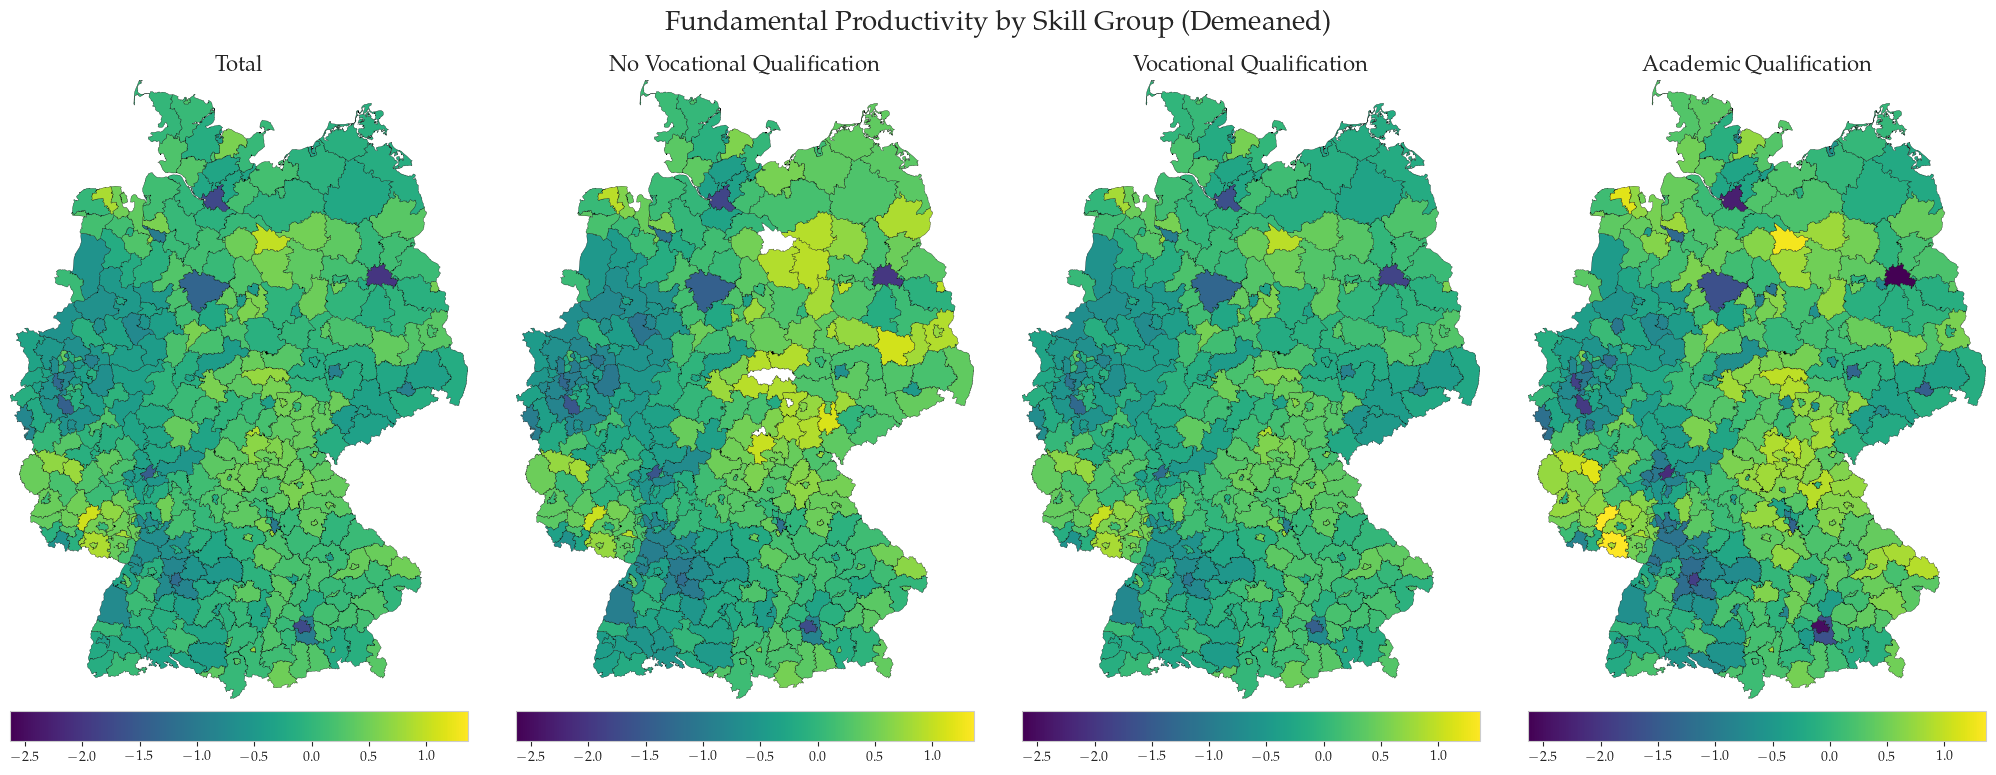

In [46]:
# === PANEL 2: FUNDAMENTAL PRODUCTIVITY (demeaned within skill group) ===
_col = "pp_fund_prod_dm"
_vmin, _vmax = data[_col].min(), data[_col].max()

fig, axes = plt.subplots(1, 4, figsize=(22, 8))

for ax, skill in zip(axes, SKILL_ORDER):
    skill_df = data.loc[data["merkmale"] == skill, ["AGS", _col]].copy()
    gdf = kreise.merge(skill_df, left_on="RS", right_on="AGS", how="left")
    plot_with_bottom_colorbar(gdf, _col, ax, "viridis", _vmin, _vmax)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(SKILL_LABELS[skill], fontsize=16, fontweight="bold")
    ax.set_axis_off()

plt.suptitle(
    r"Fundamental Productivity by Skill Group (Demeaned)",
    fontsize=20, fontweight="bold", y=0.97,
)
plt.subplots_adjust(left=0.01, right=0.99, top=0.89, bottom=0.08, wspace=0.05)
plt.savefig(plot_dir / "panel_fund_prod_by_skill.png", bbox_inches="tight", dpi=150)
plt.show()


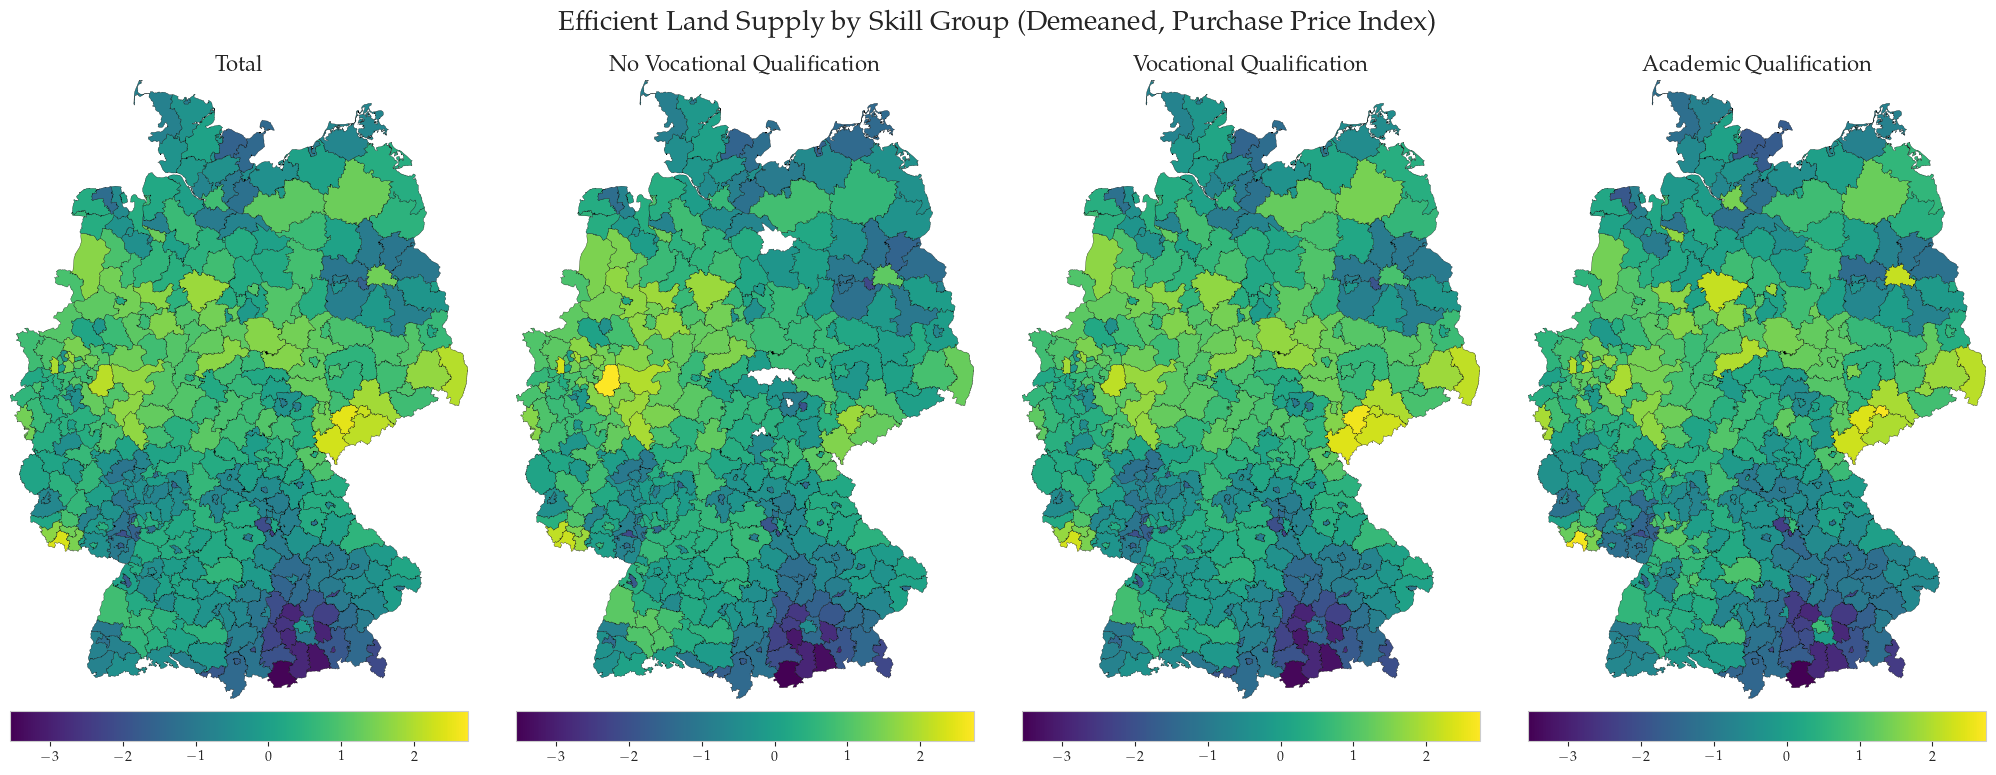

In [47]:
# === PANEL 3: EFFICIENT LAND SUPPLY (demeaned within skill group) ===
_col = "pp_eff_land_supply_dm"
_vmin, _vmax = data[_col].min(), data[_col].max()

fig, axes = plt.subplots(1, 4, figsize=(22, 8))

for ax, skill in zip(axes, SKILL_ORDER):
    skill_df = data.loc[data["merkmale"] == skill, ["AGS", _col]].copy()
    gdf = kreise.merge(skill_df, left_on="RS", right_on="AGS", how="left")
    plot_with_bottom_colorbar(gdf, _col, ax, "viridis", _vmin, _vmax)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(SKILL_LABELS[skill], fontsize=16, fontweight="bold")
    ax.set_axis_off()

plt.suptitle(
    r"Efficient Land Supply by Skill Group (Demeaned, Purchase Price Index)",
    fontsize=20, fontweight="bold", y=0.97,
)
plt.subplots_adjust(left=0.01, right=0.99, top=0.89, bottom=0.08, wspace=0.05)
plt.savefig(plot_dir / "panel_eff_land_supply_by_skill.png", bbox_inches="tight", dpi=150)
plt.show()


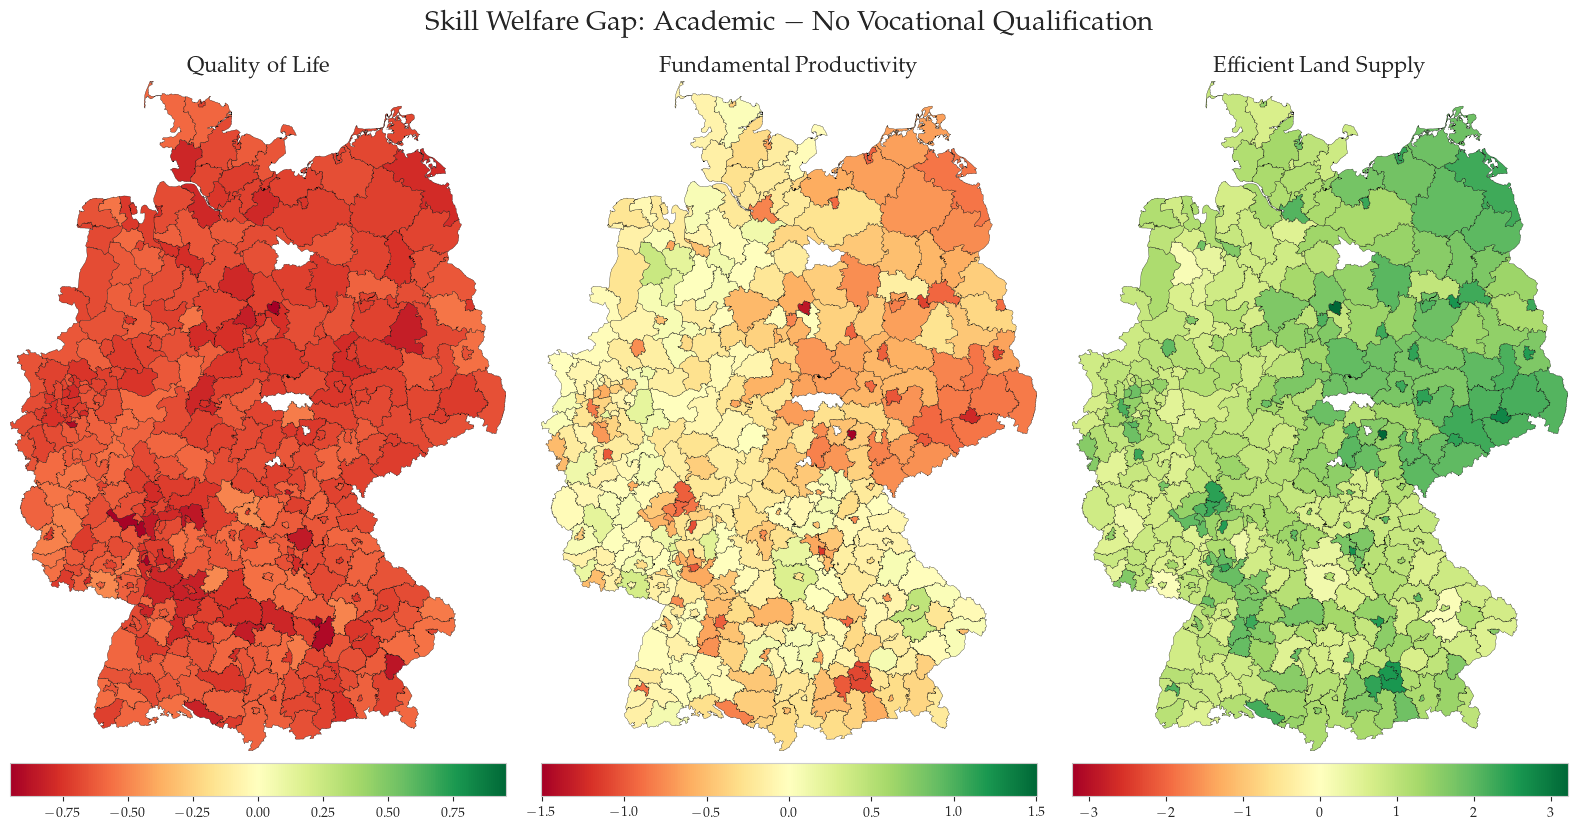

In [48]:
# === BONUS: SKILL WELFARE GAP (Academic minus No Qualification) ===
#
# Proposal: For each of the three exogenous welfare factors, plot the raw difference
#   (academic qualification) - (no vocational qualification) across German counties.
#
# Interpretation: A positive value (red) means that county rewards high-skilled workers
# more than low-skilled workers in terms of that welfare dimension. A negative value
# (blue) means the opposite — low-skilled workers have a relative welfare advantage
# there. This reveals geographic segmentation of the labour market by education level
# and speaks directly to spatial skill-sorting as predicted by Rosen-Roback theory.
#
# The diverging RdBu colormap is symmetric around zero so the zero-contour is
# unambiguous. Values are raw (not demeaned) so the difference has a natural unit
# interpretation as log-point deviations.

FACTORS = [
    ("pp_qol",             r"Quality of Life"),
    ("pp_fund_prod",       r"Fundamental Productivity"),
    ("pp_eff_land_supply", r"Efficient Land Supply"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 9))

for ax, (col, label) in zip(axes, FACTORS):
    acad = (
        data.loc[data["merkmale"] == "akademischer Berufsabschluss", ["AGS", col]]
        .rename(columns={col: "acad"})
    )
    noq = (
        data.loc[data["merkmale"] == "ohne Berufsabschluss", ["AGS", col]]
        .rename(columns={col: "noq"})
    )
    gap_df = acad.merge(noq, on="AGS")
    gap_df["skill_gap"] = gap_df["acad"] - gap_df["noq"]
    gdf = kreise.merge(gap_df[["AGS", "skill_gap"]], left_on="RS", right_on="AGS", how="left")

    abs_max = gap_df["skill_gap"].abs().max()
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("bottom", size="5%", pad=0.12)
    gdf.plot(
        column="skill_gap",
        ax=ax,
        cmap="RdYlGn",
        edgecolor="black",
        linewidth=0.2,
        legend=True,
        vmin=-abs_max,
        vmax=abs_max,
        cax=cax,
        legend_kwds={"orientation": "horizontal"},
    )
    cax.tick_params(labelsize=10)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(label, fontsize=16, fontweight="bold")
    ax.set_axis_off()

plt.suptitle(
    r"Skill Welfare Gap: Academic $-$ No Vocational Qualification",
    fontsize=20, fontweight="bold", y=0.95,
)
plt.subplots_adjust(left=0.02, right=0.98, top=0.88, bottom=0.08, wspace=0.08)
plt.savefig(plot_dir / "panel_skill_welfare_gap.png", bbox_inches="tight", dpi=150)
plt.show()
